## Getting TR from subjects

In [72]:
import nibabel as nib
import json
import os

# Path to the preprocessed NIfTI file
nifti_path = r"H:\Master's Thesis\Full dataset\derivatives\fmriprep\sub-002S6007\ses-20170331\func\sub-002S6007_ses-20170331_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"

# Load the NIfTI
img = nib.load(nifti_path)
header = img.header

# Number of volumes = shape of the 4th dimension (if 4D)
if img.ndim >= 4:
    num_volumes = img.shape[3]
else:
    # It's a 3D image (unlikely for resting state)
    num_volumes = 1

# TR (Repetition Time) in seconds is stored in the NIfTI header's pixdim[4]
# (Note: pixdim[4] is the temporal dimension's step size)
tr = header['pixdim'][4]

print(f"Number of volumes: {num_volumes}")
print(f"TR from NIfTI header: {tr} seconds")

# If a JSON sidecar exists, print the TR from there as a double-check
json_path = nifti_path.replace('.nii', '.json').replace('.nii.gz', '.json')
if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        metadata = json.load(f)
    if 'RepetitionTime' in metadata:
        json_tr = metadata['RepetitionTime']
        print(f"TR from JSON sidecar: {json_tr} seconds")
    else:
        print("No RepetitionTime in JSON sidecar.")
else:
    print("JSON sidecar not found...")

Number of volumes: 197
TR from NIfTI header: 3.0 seconds
JSON sidecar not found...


## check for file integrity

In [17]:
import pandas as pd
import os
from glob import glob

# Paths
csv_path = r"H:\Master's Thesis\pipeline\full dataset.csv"   # adjust if necessary
fmriprep_dir = r"H:\Master's Thesis\Full dataset\derivatives\fmriprep"
output_csv = r"H:\Master's Thesis\pipeline\subject_list.csv"

# Read the CSV, ensure Subject ID column is correctly named
df = pd.read_csv(csv_path)
# The column name in your file is "Subject ID" (with a space)
df.rename(columns={"Subject ID": "subject_id", "label": "dx"}, inplace=True)

# Keep only AD and CN
df = df[df["dx"].isin(["AD", "CN"])].copy()
print(f"Total AD/CN subjects in CSV: {len(df)}")

# Create a list to hold verified subjects
subjects = []

for _, row in df.iterrows():
    sub_id = row["subject_id"]
    # Construct the expected BOLD file path
    # Pattern: sub-*_ses-*_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
    bold_pattern = os.path.join(
        fmriprep_dir, sub_id, "ses-*", "func",
        f"{sub_id}_*_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"
    )
    found_files = glob(bold_pattern)
    if found_files:
        # Take the first match (should be only one)
        bold_path = found_files[0]
        subjects.append({"subject_id": sub_id, "dx": row["dx"], "bold_path": bold_path})
    else:
        print(f"WARNING: Missing BOLD for {sub_id}")

# Save verified list
sub_df = pd.DataFrame(subjects)
sub_df.to_csv(output_csv, index=False)
print(f"Verified subjects saved to {output_csv}: {len(sub_df)} subjects")
print(f"Class distribution:\n{sub_df['dx'].value_counts()}")

Total AD/CN subjects in CSV: 139
Verified subjects saved to H:\Master's Thesis\pipeline\subject_list.csv: 138 subjects
Class distribution:
dx
CN    70
AD    68
Name: count, dtype: int64


## Import the needed libraries

In [7]:
"""
Environment setup and library imports for the AD classification pipeline.
Run this script once to verify that all required packages are installed and compatible.
"""

# ------------------------------------------------------------------------------
# Core scientific computing
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# Neuroimaging
# ------------------------------------------------------------------------------
import nibabel as nib
import nilearn
from nilearn import image, masking, decomposition, connectome

# ------------------------------------------------------------------------------
# Machine learning (scikit-learn)
# ------------------------------------------------------------------------------
import sklearn
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# ------------------------------------------------------------------------------
# Hyperparameter optimization
# ------------------------------------------------------------------------------
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# ------------------------------------------------------------------------------
# Parallelism and utilities
# ------------------------------------------------------------------------------
import joblib
from joblib import Parallel, delayed
import os
import sys
from glob import glob
from tqdm.auto import tqdm

# ------------------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

# ------------------------------------------------------------------------------
# Version check
# ------------------------------------------------------------------------------
def print_versions():
    """Print versions of key packages for reproducibility."""
    print(f"Python: {sys.version}")
    print(f"numpy: {np.__version__}")
    print(f"pandas: {pd.__version__}")
    print(f"nibabel: {nib.__version__}")
    print(f"nilearn: {nilearn.__version__}")
    print(f"scikit-learn: {sklearn.__version__}")
    print(f"optuna: {optuna.__version__}")
    print(f"joblib: {joblib.__version__}")
    print(f"matplotlib: {plt.matplotlib.__version__}")
    print(f"seaborn: {sns.__version__}")

if __name__ == "__main__":
    print_versions()

Python: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
numpy: 1.24.3
pandas: 2.2.3
nibabel: 5.3.2
nilearn: 0.11.0
scikit-learn: 1.5.2
optuna: 4.1.0
joblib: 1.4.2
matplotlib: 3.9.2
seaborn: 0.13.2


## Installing the needed libraries

In [19]:
import subprocess
import sys

# Packages required for the entire project
packages = [
    "nibabel>=5.1",
    "nilearn>=0.10.4",
    "numpy>=1.26,<2",
    "pandas>=2.1",
    "scikit-learn>=1.4",
    "optuna>=3.5",
    "joblib>=1.3",
    "matplotlib>=3.8",
    "seaborn>=0.13",
    "tqdm>=4.66",
    "scipy>=1.11",
    "patsy>=0.5",
]

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Upgrade pip first
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])

# Install each package
for pkg in packages:
    print(f"Installing {pkg}...")
    install(pkg)

print("All packages installed successfully.")

Installing nibabel>=5.1...
Installing nilearn>=0.10.4...
Installing numpy>=1.26,<2...
Installing pandas>=2.1...
Installing scikit-learn>=1.4...
Installing optuna>=3.5...
Installing joblib>=1.3...
Installing matplotlib>=3.8...
Installing seaborn>=0.13...
Installing tqdm>=4.66...
Installing scipy>=1.11...
Installing patsy>=0.5...
All packages installed successfully.


## Denoising & checking the datashape

In [24]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from nilearn import image, masking

# ---------------------------------------------------------------------------
# Configuration – adjust these paths if needed
# ---------------------------------------------------------------------------
FMRIPREP_DIR = r"H:\Master's Thesis\Full dataset\derivatives\fmriprep"
SMOOTHING_FWHM = 6.0  # mm

# ---------------------------------------------------------------------------
# Nuisance regressors we will extract from confounds TSV
# ---------------------------------------------------------------------------
MOTION_COLS = [
    "trans_x", "trans_y", "trans_z",
    "rot_x", "rot_y", "rot_z",
    "trans_x_derivative1", "trans_y_derivative1", "trans_z_derivative1",
    "rot_x_derivative1", "rot_y_derivative1", "rot_z_derivative1",
]

ACOMPCOR_COLS = [
    "a_comp_cor_00", "a_comp_cor_01", "a_comp_cor_02", "a_comp_cor_03", "a_comp_cor_04",  # WM
    "a_comp_cor_05", "a_comp_cor_06", "a_comp_cor_07", "a_comp_cor_08", "a_comp_cor_09",  # CSF
]

# ---------------------------------------------------------------------------
# Helper: find the preprocessed BOLD, brain mask, and confounds for a subject
# ---------------------------------------------------------------------------
def _find_subject_files(subject_id):
    """Locate the functional files inside fmriprep derivatives for a given subject."""
    subj_dir = os.path.join(FMRIPREP_DIR, subject_id)
    if not os.path.isdir(subj_dir):
        raise FileNotFoundError(f"Subject directory not found: {subj_dir}")

    # Find all session folders
    sess_dirs = [
        d for d in os.listdir(subj_dir)
        if os.path.isdir(os.path.join(subj_dir, d)) and d.startswith("ses-")
    ]
    if not sess_dirs:
        raise FileNotFoundError(f"No session folder found for {subject_id}")
    # Take the first session (should be only one per subject in your data)
    ses = sess_dirs[0]

    func_dir = os.path.join(subj_dir, ses, "func")

    # Bold file pattern: *_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
    bold_candidates = [
        f for f in os.listdir(func_dir)
        if "space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz" in f
    ]
    if not bold_candidates:
        raise FileNotFoundError(f"No preproc BOLD file found for {subject_id}")
    bold_path = os.path.join(func_dir, bold_candidates[0])

    # Brain mask pattern: *_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz
    mask_candidates = [
        f for f in os.listdir(func_dir)
        if "space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz" in f
    ]
    if not mask_candidates:
        raise FileNotFoundError(f"No brain mask file found for {subject_id}")
    mask_path = os.path.join(func_dir, mask_candidates[0])

    # Confounds file: *_desc-confounds_timeseries.tsv
    conf_candidates = [
        f for f in os.listdir(func_dir)
        if "desc-confounds_timeseries.tsv" in f
    ]
    if not conf_candidates:
        raise FileNotFoundError(f"No confounds TSV found for {subject_id}")
    conf_path = os.path.join(func_dir, conf_candidates[0])

    return bold_path, mask_path, conf_path


# ---------------------------------------------------------------------------
# Main cleaning function
# ---------------------------------------------------------------------------
def clean_subject(subject_id):
    """
    Load, denoise, smooth, and mask a subject's rs-fMRI data.
    Returns
    -------
    clean_data : 2D np.ndarray (n_voxels, n_timepoints)
    mask_img : Nifti1Image, the resampled brain mask used
    """
    print(f"Processing {subject_id}...")

    # Locate files
    bold_path, mask_path, conf_path = _find_subject_files(subject_id)

    # Load images
    bold_img = nib.load(bold_path)
    mask_img_orig = nib.load(mask_path)

    # --- FIX: Resample mask to BOLD image's grid and affine ---
    mask_img = image.resample_to_img(
        mask_img_orig, bold_img, interpolation="nearest"
    )

    # Load confounds
    conf_df = pd.read_csv(conf_path, sep="\t")

    # Select available nuisance regressors
    available_motion = [c for c in MOTION_COLS if c in conf_df.columns]
    available_acomp = [c for c in ACOMPCOR_COLS if c in conf_df.columns]
    nuisance_cols = available_motion + available_acomp

    if not nuisance_cols:
        raise ValueError(f"No nuisance columns found for {subject_id}")

    # Extract nuisance regressors (replace NaN with column mean)
    nuisance_mat = conf_df[nuisance_cols].values.astype(np.float64)
    col_means = np.nanmean(nuisance_mat, axis=0)
    nan_inds = np.where(np.isnan(nuisance_mat))
    nuisance_mat[nan_inds] = np.take(col_means, nan_inds[1])

    # Add intercept
    intercept = np.ones((nuisance_mat.shape[0], 1))
    design = np.hstack([intercept, nuisance_mat])

    # Apply mask to 4D BOLD -> 2D array (voxels, time)
    masked = masking.apply_mask(bold_img, mask_img)  # (n_timepoints, n_voxels) by default
    # Transpose to (n_voxels, n_timepoints) for regression
    masked = masked.T

    # Nuisance regression (batch linear regression)
    # Solve: beta = inv(D' D) D' Y; residuals = Y - D beta
    beta = np.linalg.lstsq(design, masked.T, rcond=None)[0]  # (n_regressors, n_voxels)
    fitted = design @ beta  # (n_timepoints, n_voxels)
    residuals = masked - fitted.T  # (n_voxels, n_timepoints)

    # Build a residualised 4D image (back to nilearn image for smoothing)
    # We need to reconstruct a 4D image using the mask
    residual_img = masking.unmask(residuals.T, mask_img)  # (x, y, z, t)

    # Smooth the residualised 4D image
    smoothed_img = image.smooth_img(residual_img, fwhm=SMOOTHING_FWHM)

    # Re-apply mask to smoothed image
    clean_data = masking.apply_mask(smoothed_img, mask_img)  # (n_timepoints, n_voxels)
    clean_data = clean_data.T  # (n_voxels, n_timepoints)

    print(f"  Output shape: {clean_data.shape} (voxels, timepoints)")
    return clean_data, mask_img


# ---------------------------------------------------------------------------
# Quick test (runs only when executing this script directly)
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    test_subject = "sub-002S6007"
    data, mask = clean_subject(test_subject)
    print(f"Test passed. Data shape: {data.shape}, mask shape: {mask.shape}")

Processing sub-002S6007...


C:\Users\Alireza217\AppData\Local\Temp\ipykernel_11300\3694203204.py:100: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_img = image.resample_to_img(
C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


  Output shape: (53901, 197) (voxels, timepoints)
Test passed. Data shape: (53901, 197), mask shape: (64, 64, 48)


In [28]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import image, masking
from nilearn.datasets import load_mni152_brain_mask

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
FMRIPREP_DIR = r"H:\Master's Thesis\Full dataset\derivatives\fmriprep"
SUBJ_LIST = r"H:\Master's Thesis\pipeline\subject_list.csv"
OUTPUT_DIR = r"H:\Master's Thesis\pipeline\cleaned_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SMOOTHING_FWHM = 6.0  # mm

MOTION_COLS = [
    "trans_x", "trans_y", "trans_z",
    "rot_x", "rot_y", "rot_z",
    "trans_x_derivative1", "trans_y_derivative1", "trans_z_derivative1",
    "rot_x_derivative1", "rot_y_derivative1", "rot_z_derivative1",
]

ACOMPCOR_COLS = [
    "a_comp_cor_00", "a_comp_cor_01", "a_comp_cor_02", "a_comp_cor_03", "a_comp_cor_04",
    "a_comp_cor_05", "a_comp_cor_06", "a_comp_cor_07", "a_comp_cor_08", "a_comp_cor_09",
]

# ---------------------------------------------------------------------------
# Common MNI template and mask (2 mm, same as your data space)
# ---------------------------------------------------------------------------
print("Loading MNI152 2mm brain mask...")
MNI_MASK_IMG = load_mni152_brain_mask(resolution=2)   # returns a Nifti1Image
# Also get the template itself for resampling target
MNI_TEMPLATE_IMG = load_mni152_brain_mask(resolution=2)  # same, we can use the mask as target space
# The mask is binary; we'll use its affine and shape as resampling target

# ---------------------------------------------------------------------------
# Helper: locate files for a subject
# ---------------------------------------------------------------------------
def _find_subject_files(subject_id):
    subj_dir = os.path.join(FMRIPREP_DIR, subject_id)
    if not os.path.isdir(subj_dir):
        raise FileNotFoundError(f"Subject directory not found: {subj_dir}")

    sess_dirs = [
        d for d in os.listdir(subj_dir)
        if os.path.isdir(os.path.join(subj_dir, d)) and d.startswith("ses-")
    ]
    if not sess_dirs:
        raise FileNotFoundError(f"No session folder found for {subject_id}")
    ses = sess_dirs[0]
    func_dir = os.path.join(subj_dir, ses, "func")

    bold_candidates = [
        f for f in os.listdir(func_dir)
        if "space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz" in f
    ]
    if not bold_candidates:
        raise FileNotFoundError(f"No preproc BOLD file found for {subject_id}")
    bold_path = os.path.join(func_dir, bold_candidates[0])

    mask_candidates = [
        f for f in os.listdir(func_dir)
        if "space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz" in f
    ]
    if not mask_candidates:
        raise FileNotFoundError(f"No brain mask file found for {subject_id}")
    mask_path = os.path.join(func_dir, mask_candidates[0])

    conf_candidates = [
        f for f in os.listdir(func_dir)
        if "desc-confounds_timeseries.tsv" in f
    ]
    if not conf_candidates:
        raise FileNotFoundError(f"No confounds TSV found for {subject_id}")
    conf_path = os.path.join(func_dir, conf_candidates[0])

    return bold_path, mask_path, conf_path

# ---------------------------------------------------------------------------
# Denoising function (now resamples to common MNI mask at the end)
# ---------------------------------------------------------------------------
def clean_subject_common(subject_id, target_mask_img, target_template_img):
    """
    Returns cleaned data as 2D array (n_common_voxels, n_timepoints)
    using a fixed common MNI mask.
    """
    print(f"Processing {subject_id}...")

    bold_path, mask_path, conf_path = _find_subject_files(subject_id)

    bold_img = nib.load(bold_path)
    mask_img_orig = nib.load(mask_path)

    # Resample subject mask to BOLD grid
    mask_img = image.resample_to_img(
        mask_img_orig, bold_img, interpolation="nearest", force_resample=True
    )

    conf_df = pd.read_csv(conf_path, sep="\t")

    available_motion = [c for c in MOTION_COLS if c in conf_df.columns]
    available_acomp = [c for c in ACOMPCOR_COLS if c in conf_df.columns]
    nuisance_cols = available_motion + available_acomp

    if not nuisance_cols:
        raise ValueError(f"No nuisance columns found for {subject_id}")

    nuisance_mat = conf_df[nuisance_cols].values.astype(np.float64)
    col_means = np.nanmean(nuisance_mat, axis=0)
    inds = np.where(np.isnan(nuisance_mat))
    nuisance_mat[inds] = np.take(col_means, inds[1])

    intercept = np.ones((nuisance_mat.shape[0], 1))
    design = np.hstack([intercept, nuisance_mat])

    # Apply mask and regress
    masked = masking.apply_mask(bold_img, mask_img)  # (time, voxels)
    masked = masked.T  # (voxels, time)

    beta = np.linalg.lstsq(design, masked.T, rcond=None)[0]
    fitted = design @ beta
    residuals = masked - fitted.T  # (voxels, time)

    # Reconstruct 4D in subject's BOLD space (with subject's specific FOV)
    residual_img = masking.unmask(residuals.T, mask_img)

    # Smooth
    smoothed_img = image.smooth_img(residual_img, fwhm=SMOOTHING_FWHM)

    # --- Resample to common MNI template grid ---
    # Use the MNI mask image as target space (same affine/shape for all)
    resampled_smoothed = image.resample_to_img(
        smoothed_img, target_template_img, interpolation="continuous"
    )

    # Apply the common brain mask
    common_masked = masking.apply_mask(resampled_smoothed, target_mask_img)  # (time, voxels)
    common_masked = common_masked.T  # (voxels, time)

    n_vox = common_masked.shape[0]
    print(f"  Common-masked shape: {common_masked.shape}")
    return common_masked

# ---------------------------------------------------------------------------
# Batch process all subjects
# ---------------------------------------------------------------------------
df = pd.read_csv(SUBJ_LIST)

# Save the common mask once as well
common_mask_data = MNI_MASK_IMG.get_fdata().astype(bool)
np.save(os.path.join(OUTPUT_DIR, "common_mask_data.npy"), common_mask_data)
nib.save(MNI_MASK_IMG, os.path.join(OUTPUT_DIR, "common_mask.nii.gz"))
print(f"Common mask saved. Voxels in mask: {common_mask_data.sum()}")

failed_subjects = []

for idx, row in df.iterrows():
    sub_id = row["subject_id"]
    dx = row["dx"]
    try:
        clean_data = clean_subject_common(sub_id, MNI_MASK_IMG, MNI_TEMPLATE_IMG)
    except Exception as e:
        print(f"Failed on {sub_id}: {e}")
        failed_subjects.append(sub_id)
        continue

    np.save(
        os.path.join(OUTPUT_DIR, f"{sub_id}_cleaned.npy"),
        clean_data.astype(np.float32)
    )
    print(f"Saved {sub_id} ({dx})")

print(f"\nProcessing finished.")
print(f"Successfully processed: {len(df) - len(failed_subjects)} subjects")
if failed_subjects:
    print(f"Failed subjects: {failed_subjects}")

Loading MNI152 2mm brain mask...
Common mask saved. Voxels in mask: 235375
Processing sub-003S6264...


C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
C:\Users\Alireza217\AppData\Local\Temp\ipykernel_11300\1330007186.py:135: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_smoothed = image.resample_to_img(
C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


  Common-masked shape: (235375, 197)
Saved sub-003S6264 (AD)
Processing sub-003S6833...


C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
C:\Users\Alireza217\AppData\Local\Temp\ipykernel_11300\1330007186.py:135: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_smoothed = image.resample_to_img(
C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


  Common-masked shape: (235375, 197)
Saved sub-003S6833 (AD)
Processing sub-009S5027...


...

  Common-masked shape: (235375, 197)
Saved sub-941S6054 (CN)
Processing sub-941S6080...


C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
C:\Users\Alireza217\AppData\Local\Temp\ipykernel_11300\1330007186.py:135: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_smoothed = image.resample_to_img(
C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


  Common-masked shape: (235375, 197)
Saved sub-941S6080 (CN)
Processing sub-002S6007...


C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
C:\Users\Alireza217\AppData\Local\Temp\ipykernel_11300\1330007186.py:135: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_smoothed = image.resample_to_img(
C:\Users\Alireza217\anaconda3\Lib\site-packages\nilearn\image\resampling.py:807: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


  Common-masked shape: (235375, 197)
Saved sub-002S6007 (CN)

Processing finished.
Successfully processed: 138 subjects


In [13]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from nilearn import decomposition, masking

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
CLEANED_DIR = r"H:\Master's Thesis\pipeline\cleaned_data"
SUBJ_LIST = r"H:\Master's Thesis\pipeline\subject_list.csv"
OUTPUT_ICA_DIR = r"H:\Master's Thesis\pipeline\ica_output"
os.makedirs(OUTPUT_ICA_DIR, exist_ok=True)

N_COMPONENTS = 40

# ---------------------------------------------------------------------------
# 1. Load common mask
# ---------------------------------------------------------------------------
common_mask_path = os.path.join(CLEANED_DIR, "common_mask.nii.gz")
mask_img = nib.load(common_mask_path)
mask_data = mask_img.get_fdata().astype(bool)
print(f"Common mask loaded: {mask_img.shape}, voxels in mask: {mask_data.sum()}")

# ---------------------------------------------------------------------------
# 2. Convert each subject's cleaned 2D array to 4D NIfTI and save to disk
# ---------------------------------------------------------------------------
df = pd.read_csv(SUBJ_LIST)
subject_ids = df["subject_id"].tolist()

niimg_paths = []

for sub_id in subject_ids:
    fpath = os.path.join(CLEANED_DIR, f"{sub_id}_cleaned.npy")
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"Missing cleaned file for {sub_id}")

    # Load (time, voxels) – already converted
    data_2d = np.load(fpath).astype(np.float32)   # shape (n_timepoints, n_voxels)

    # Reconstruct 4D image using the common mask
    img_4d = masking.unmask(data_2d, mask_img)    # (x, y, z, t)

    # Save as compressed NIfTI
    out_path = os.path.join(OUTPUT_ICA_DIR, f"{sub_id}_cleaned.nii.gz")
    nib.save(img_4d, out_path)
    niimg_paths.append(out_path)
    print(f"Saved 4D image for {sub_id} ({data_2d.shape[0]} timepoints)")

print(f"All 4D images saved. Total: {len(niimg_paths)}")

# ---------------------------------------------------------------------------
# 3. Run CanICA on the list of NIfTI file paths
# ---------------------------------------------------------------------------
print("Running CanICA...")
ica = decomposition.CanICA(
    n_components=N_COMPONENTS,
    mask=mask_img,
    memory="nilearn_cache",
    memory_level=2,
    verbose=1,
    random_state=42,
    n_jobs=1,
)
ica.fit(niimg_paths)   # list of file paths – nilearn loads them one by one

# Save group-level spatial maps
components_img = ica.masker_.inverse_transform(ica.components_)
components_path = os.path.join(OUTPUT_ICA_DIR, "group_ica_components.nii.gz")
nib.save(components_img, components_path)
print(f"Saved group IC maps to {components_path}")

# ---------------------------------------------------------------------------
# 4. Dual regression – use the already saved 4D NIfTI paths
# ---------------------------------------------------------------------------
for i, (sub_id, img_path) in enumerate(zip(subject_ids, niimg_paths)):
    # Load the 4D image from disk (nilearn handles this internally)
    ts = ica.transform(img_path)   # shape (n_timepoints, n_components)
    np.save(os.path.join(OUTPUT_ICA_DIR, f"{sub_id}_ica_timeseries.npy"), ts)
    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/{len(subject_ids)} subjects")

print("Dual regression complete. All time series saved.")

Common mask loaded: (99, 117, 95), voxels in mask: 235375
Saved 4D image for sub-003S6264 (197 timepoints)
Saved 4D image for sub-003S6833 (197 timepoints)
Saved 4D image for sub-009S5027 (105 timepoints)
Saved 4D image for sub-009S5037 (105 timepoints)
Saved 4D image for sub-009S5224 (105 timepoints)
Saved 4D image for sub-009S5252 (105 timepoints)
Saved 4D image for sub-011S4827 (105 timepoints)
Saved 4D image for sub-011S4845 (105 timepoints)
Saved 4D image for sub-011S4906 (105 timepoints)
Saved 4D image for sub-011S4912 (105 timepoints)
Saved 4D image for sub-011S4949 (105 timepoints)
Saved 4D image for sub-011S6303 (197 timepoints)
Saved 4D image for sub-014S4039 (105 timepoints)
Saved 4D image for sub-014S4615 (105 timepoints)
Saved 4D image for sub-019S5019 (140 timepoints)
Saved 4D image for sub-023S4501 (105 timepoints)
Saved 4D image for sub-023S5120 (105 timepoints)
Saved 4D image for sub-023S5241 (105 timepoints)
Saved 4D image for sub-024S4223 (105 timepoints)
Saved 4D im

[CanICA.fit] Loading data from None.

[CanICA.fit] Resampling mask

[CanICA.fit] Loading data

[CanICA.fit] Loading data from Nifti1Image('H:\Master's Thesis\pipeline\ica_output\sub-003S6264_cleaned.nii.gz')

...

[CanICA.fit] Smoothing images

[CanICA.fit] Extracting region signals

[CanICA.fit] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling sklearn.utils.extmath.randomized_svd...
randomized_svd(array([[-0.000231, ...,  0.000587],
       ...,
       [ 0.001685, ..., -0.0013  ]], dtype=float32), n_components=40, transpose=True, random_state=42, n_iter=3)
___________________________________________________randomized_svd - 7.8s, 0.1min
________________________________________________________________________________
[Memory] Calling sklearn.decomposition._fastica.fastica...
fastica(array([[ 8.599433e-04, ...,  2.024045e-03],
       ...,
       [ 1.493993e-03, ..., -3.530303e-05]]), whiten='arbitrary-variance', fun='cube', random_state=1608637542)
_________________________________________________________fastica - 28.8s, 0.5min
________________________________________________________________________________
[Memory] Calling sklearn.decomposition._fastica.fastica...
fastica(array([[ 8.599433e-04, ...,  2.024045e-03],
       ...,
    

ValueError: File not found: 'H'

## Conversion to (time, voxels) format

In [3]:
import os
import numpy as np
import pandas as pd

CLEANED_DIR = r"H:\Master's Thesis\pipeline\cleaned_data"
SUBJ_LIST = r"H:\Master's Thesis\pipeline\subject_list.csv"

df = pd.read_csv(SUBJ_LIST)
subject_ids = df["subject_id"].tolist()

for sub_id in subject_ids:
    fpath = os.path.join(CLEANED_DIR, f"{sub_id}_cleaned.npy")
    # Load as (voxels, time)
    data_vox_x_time = np.load(fpath)          # shape (n_voxels, n_timepoints)
    # Transpose to (time, voxels), force C-order
    data_time_x_vox = np.ascontiguousarray(data_vox_x_time.T.astype(np.float32))
    # Overwrite with the transposed version
    np.save(fpath, data_time_x_vox)
    print(f"Converted {sub_id} to (time, voxels)")

print("All files converted.")

Converted sub-003S6264 to (time, voxels)
Converted sub-003S6833 to (time, voxels)
Converted sub-009S5027 to (time, voxels)
Converted sub-009S5037 to (time, voxels)
Converted sub-009S5224 to (time, voxels)
Converted sub-009S5252 to (time, voxels)
Converted sub-011S4827 to (time, voxels)
Converted sub-011S4845 to (time, voxels)
Converted sub-011S4906 to (time, voxels)
Converted sub-011S4912 to (time, voxels)
Converted sub-011S4949 to (time, voxels)
Converted sub-011S6303 to (time, voxels)
Converted sub-014S4039 to (time, voxels)
Converted sub-014S4615 to (time, voxels)
Converted sub-019S5019 to (time, voxels)
Converted sub-023S4501 to (time, voxels)
Converted sub-023S5120 to (time, voxels)
Converted sub-023S5241 to (time, voxels)
Converted sub-024S4223 to (time, voxels)
Converted sub-024S4280 to (time, voxels)
Converted sub-024S4905 to (time, voxels)
Converted sub-024S5054 to (time, voxels)
Converted sub-032S6600 to (time, voxels)
Converted sub-032S6602 to (time, voxels)
Converted sub-03

## Check for subject shape

In [7]:
import os
import numpy as np
import pandas as pd

CLEANED_DIR = r"H:\Master's Thesis\pipeline\cleaned_data"
SUBJ_LIST = r"H:\Master's Thesis\pipeline\subject_list.csv"

df = pd.read_csv(SUBJ_LIST)
test_sub = df["subject_id"].iloc[0]
test_fpath = os.path.join(CLEANED_DIR, f"{test_sub}_cleaned.npy")

# Check current shape
arr = np.load(test_fpath)
print(f"Current shape of {test_sub}: {arr.shape}")

# If shape is (voxels, time) i.e., first dimension ≈235375, convert all
if arr.shape[0] > 1000:   # it's (voxels, time)
    print("Converting all files to (time, voxels)...")
    for sub_id in df["subject_id"]:
        fpath = os.path.join(CLEANED_DIR, f"{sub_id}_cleaned.npy")
        data_vox_x_time = np.load(fpath)          # (voxels, time)
        data_time_x_vox = np.ascontiguousarray(data_vox_x_time.T.astype(np.float32))
        np.save(fpath, data_time_x_vox)
    print("Conversion done. Re-checking shape:")
    arr2 = np.load(test_fpath)
    print(f"New shape: {arr2.shape}")   # should be (timepoints, 235375)
else:
    print("Shape is already (time, voxels). No conversion needed.")

Current shape of sub-003S6264: (197, 235375)
Shape is already (time, voxels). No conversion needed.


## Check for corrupted subjects

In [17]:
import os
import nibabel as nib

ica_dir = r"H:\Master's Thesis\pipeline\ica_output"
corrupted = []

for fname in sorted(os.listdir(ica_dir)):
    if fname.endswith("_cleaned.nii.gz"):
        fpath = os.path.join(ica_dir, fname)
        try:
            nib.load(fpath)
        except Exception as e:
            print(f"Corrupt: {fname}")
            corrupted.append(fname)

print(f"\nTotal corrupted: {len(corrupted)}")


Total corrupted: 0


In [21]:
import numpy as np
import nibabel as nib
from nilearn import masking

clean_dir = r"H:\Master's Thesis\pipeline\cleaned_data"
ica_dir = r"H:\Master's Thesis\pipeline\ica_output"

# Load common mask (unchanged)
mask_img = nib.load(os.path.join(clean_dir, "common_mask.nii.gz"))

for fname in corrupted:
    # Extract subject ID: e.g., "sub-041S6785_cleaned.nii.gz" -> "sub-041S6785"
    sub_id = fname.replace("_cleaned.nii.gz", "")
    npy_path = os.path.join(clean_dir, f"{sub_id}_cleaned.npy")
    if not os.path.exists(npy_path):
        print(f"Missing .npy for {sub_id} – cannot rebuild")
        continue
    data = np.load(npy_path)            # shape (time, voxels)
    img_4d = masking.unmask(data, mask_img)
    out_path = os.path.join(ica_dir, fname)
    nib.save(img_4d, out_path)
    print(f"Rebuilt {fname}")

In [23]:
# Dual regression – robust version, uses existing variables
failed = []

for i, (sub_id, img_path) in enumerate(zip(subject_ids, niimg_paths)):
    out_path = os.path.join(OUTPUT_ICA_DIR, f"{sub_id}_ica_timeseries.npy")
    if os.path.exists(out_path):
        # Already processed, skip
        continue
    try:
        ts_list = ica.transform([img_path])
        ts = ts_list[0]
        np.save(out_path, ts)
    except Exception as e:
        print(f"Failed on {sub_id}: {e}")
        failed.append(sub_id)
        continue
    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/{len(subject_ids)} subjects")

print(f"Dual regression finished. Failed subjects: {failed}")

Failed on sub-037S6144: Error -3 while decompressing data: invalid stored block lengths


[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

...

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

Dual regression finished. Failed subjects: ['sub-037S6144']


In [25]:
import numpy as np
import nibabel as nib
from nilearn import masking

clean_dir = r"H:\Master's Thesis\pipeline\cleaned_data"
ica_dir = r"H:\Master's Thesis\pipeline\ica_output"

# Load common mask
mask_img = nib.load(os.path.join(clean_dir, "common_mask.nii.gz"))

# Load cleaned (time, voxels) array
npy_path = os.path.join(clean_dir, "sub-037S6144_cleaned.npy")
data = np.load(npy_path)          # shape (n_timepoints, n_voxels)

# Rebuild 4D image
img_4d = masking.unmask(data, mask_img)

# Overwrite the corrupted file
out_path = os.path.join(ica_dir, "sub-037S6144_cleaned.nii.gz")
nib.save(img_4d, out_path)
print(f"Rebuilt {out_path}")

Rebuilt H:\Master's Thesis\pipeline\ica_output\sub-037S6144_cleaned.nii.gz


In [27]:
img_path = os.path.join(ica_dir, "sub-037S6144_cleaned.nii.gz")
ts_list = ica.transform([img_path])
ts = ts_list[0]
np.save(os.path.join(ica_dir, f"sub-037S6144_ica_timeseries.npy"), ts)
print("sub-037S6144 dual regression done. Shape:", ts.shape)

[CanICA.wrapped] Resampling images

sub-037S6144 dual regression done. Shape: (197, 40)


In [29]:
import os
import numpy as np

ica_dir = r"H:\Master's Thesis\pipeline\ica_output"
ts_files = [f for f in os.listdir(ica_dir) if f.endswith("_ica_timeseries.npy")]
print(f"Number of time series files: {len(ts_files)}")

# Check a random one
sample = np.load(os.path.join(ica_dir, ts_files[0]))
print(f"Sample shape: {sample.shape}")

Number of time series files: 138
Sample shape: (197, 40)


## Feature extraction and saving as a file

In [36]:
import os
import numpy as np
import pandas as pd
from nilearn.connectome import ConnectivityMeasure
from sklearn.covariance import LedoitWolf

# ---------------------------------------------------------------------------
# Paths: if you want to rerun the code, change the directories accordingly
# ---------------------------------------------------------------------------
ICA_DIR = r"H:\Master's Thesis\pipeline\ica_output"
SUBJ_LIST = r"H:\Master's Thesis\pipeline\subject_list.csv"
OUT_DIR = r"H:\Master's Thesis\pipeline\features"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
WIN_SIZE = 20       # volumes (20 × 3 s = 60 s)
STEP_SIZE = 10      # volumes (50% overlap)

# ---------------------------------------------------------------------------
# Load subject list and labels
# ---------------------------------------------------------------------------
df = pd.read_csv(SUBJ_LIST)
subject_ids = df["subject_id"].tolist()
labels = df["dx"].tolist()

# ---------------------------------------------------------------------------
# Prepare connectivity measures
# ---------------------------------------------------------------------------
# Static FC
static_measure = ConnectivityMeasure(kind="correlation")

# Partial correlation – regularised with Ledoit-Wolf
partial_measure = ConnectivityMeasure(kind="partial correlation", cov_estimator=LedoitWolf())

feature_list = []
valid_ids = []
valid_labels = []

for sub_id, label in zip(subject_ids, labels):
    ts_path = os.path.join(ICA_DIR, f"{sub_id}_ica_timeseries.npy")
    if not os.path.exists(ts_path):
        print(f"Missing time series for {sub_id}, skipping.")
        continue

    ts = np.load(ts_path)   # shape (T, 40)
    n_vols = ts.shape[0]

    # Check minimum length for sliding window
    if n_vols < WIN_SIZE:
        print(f"{sub_id}: only {n_vols} volumes (< {WIN_SIZE}), skipping sliding window dynamic FC.")
        continue

    # Static FC
    static_matrix = static_measure.fit_transform([ts])[0]   # (40, 40)

    # Dynamic FC – sliding windows
    n_windows = (n_vols - WIN_SIZE) // STEP_SIZE + 1
    window_matrices = []
    for w in range(n_windows):
        start = w * STEP_SIZE
        win_ts = ts[start : start + WIN_SIZE, :]
        # Compute correlation for this window
        corr = static_measure.fit_transform([win_ts])[0]
        window_matrices.append(corr)
    window_matrices = np.array(window_matrices)  # (n_windows, 40, 40)

    # Summary: mean and std across windows
    dynamic_mean = window_matrices.mean(axis=0)  # (40, 40)
    dynamic_std  = window_matrices.std(axis=0)   # (40, 40)

    # Partial correlation
    partial_matrix = partial_measure.fit_transform([ts])[0]  # (40, 40)

    # Vectorise upper triangles (excluding diagonal)
    triu_idx = np.triu_indices(40, k=1)
    static_vec = static_matrix[triu_idx]
    dyn_mean_vec = dynamic_mean[triu_idx]
    dyn_std_vec  = dynamic_std[triu_idx]
    partial_vec  = partial_matrix[triu_idx]

    # Concatenate all features
    feature_vec = np.concatenate([static_vec, dyn_mean_vec, dyn_std_vec, partial_vec])
    feature_list.append(feature_vec)
    valid_ids.append(sub_id)
    valid_labels.append(label)

# ---------------------------------------------------------------------------
# Create final arrays
# ---------------------------------------------------------------------------
X = np.array(feature_list, dtype=np.float32)   # (n_subjects, 3120)
y = np.array(valid_labels)

# Save
np.save(os.path.join(OUT_DIR, "X_features.npy"), X)
np.save(os.path.join(OUT_DIR, "y_labels.npy"), y)

# Also save a clean subject list for downstream use
pd.DataFrame({"subject_id": valid_ids, "dx": valid_labels}).to_csv(
    os.path.join(OUT_DIR, "valid_subjects.csv"), index=False
)

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Features saved to {OUT_DIR}")

Feature matrix shape: (138, 3120)
Labels shape: (138,)
Features saved to H:\Master's Thesis\pipeline\features


## Training and testing the main classification SVM and cross-fold validation

In [39]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import decomposition, masking
from nilearn.connectome import ConnectivityMeasure
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
import optuna
from optuna.samplers import TPESampler

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
CLEANED_DIR = r"H:\Master's Thesis\pipeline\cleaned_data"
ICA_DIR = r"H:\Master's Thesis\pipeline\ica_output"
OUT_DIR = r"H:\Master's Thesis\pipeline\results"
os.makedirs(OUT_DIR, exist_ok=True)

SUBJ_CSV = r"H:\Master's Thesis\pipeline\features\valid_subjects.csv"  # from feature script
COMMON_MASK = os.path.join(CLEANED_DIR, "common_mask.nii.gz")

# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
N_OUTER_SPLITS = 5       # 5-fold nested CV
N_INNER_SPLITS = 5       # inner CV for Optuna
N_COMPONENTS = 40
WIN_SIZE = 20
STEP_SIZE = 10

# ---------------------------------------------------------------------------
# Load subject list & labels
# ---------------------------------------------------------------------------
df = pd.read_csv(SUBJ_CSV)
subjects = df["subject_id"].tolist()
labels = df["dx"].map({"CN": 0, "AD": 1}).values   # 0 = CN, 1 = AD

# NIfTI paths (already created in ICA step)
niimg_paths = [os.path.join(ICA_DIR, f"{s}_cleaned.nii.gz") for s in subjects]

# common mask image
mask_img = nib.load(COMMON_MASK)

# ---------------------------------------------------------------------------
# Feature extraction function (for a set of subject NIfTI paths)
# ---------------------------------------------------------------------------
def extract_features_from_ica(ica_obj, niimg_list):
    """
    Given a fitted CanICA object and list of NIfTI paths,
    return connectivity feature matrix (n_subjects, 3120).
    """
    static_measure = ConnectivityMeasure(kind="correlation")
    partial_measure = ConnectivityMeasure(kind="partial correlation",
                                          cov_estimator=LedoitWolf())
    feats = []
    for path in niimg_list:
        # dual regression: subject-specific time series
        ts_list = ica_obj.transform([path])   # list of one array
        ts = ts_list[0]                       # (T, 40)
        n_vols = ts.shape[0]

        # static
        static_mat = static_measure.fit_transform([ts])[0]

        # dynamic (mean & std)
        n_wins = (n_vols - WIN_SIZE) // STEP_SIZE + 1
        wins = []
        for w in range(n_wins):
            start = w * STEP_SIZE
            win_ts = ts[start:start+WIN_SIZE, :]
            wins.append(static_measure.fit_transform([win_ts])[0])
        wins = np.array(wins)   # (n_windows, 40, 40)
        dyn_mean = wins.mean(axis=0)
        dyn_std = wins.std(axis=0)

        # partial
        partial_mat = partial_measure.fit_transform([ts])[0]

        # vectorise upper triangles
        triu = np.triu_indices(40, k=1)
        vec = np.concatenate([
            static_mat[triu],
            dyn_mean[triu],
            dyn_std[triu],
            partial_mat[triu]
        ])
        feats.append(vec)
    return np.array(feats, dtype=np.float32)

# ---------------------------------------------------------------------------
# Outer stratified CV
# ---------------------------------------------------------------------------
outer_cv = StratifiedKFold(n_splits=N_OUTER_SPLITS, shuffle=True, random_state=42)

all_test_acc = []
all_test_auc = []
all_test_f1 = []
all_confusion = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(subjects, labels)):
    print(f"\n===== Outer Fold {fold+1}/{N_OUTER_SPLITS} =====")
    train_subj = [subjects[i] for i in train_idx]
    test_subj  = [subjects[i] for i in test_idx]
    train_paths = [niimg_paths[i] for i in train_idx]
    test_paths  = [niimg_paths[i] for i in test_idx]
    y_train_true = labels[train_idx]
    y_test_true  = labels[test_idx]

    # --- Step 1: Group ICA on training set only ---
    print("  Fitting group ICA on training subjects ...")
    ica = decomposition.CanICA(
        n_components=N_COMPONENTS,
        mask=mask_img,
        memory="nilearn_cache",
        memory_level=2,
        random_state=42,
        n_jobs=1,
        verbose=0
    )
    ica.fit(train_paths)

    # --- Step 2: Extract features for train and test ---
    print("  Extracting features ...")
    X_train = extract_features_from_ica(ica, train_paths)
    X_test  = extract_features_from_ica(ica, test_paths)

    # --- Step 3: Feature scaling ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # --- Step 4: Optuna hyperparameter optimisation (inner CV) ---
    def objective(trial):
        C = trial.suggest_float("C", 1e-3, 1e3, log=True)
        clf = SVC(kernel="linear", C=C, class_weight="balanced", random_state=42)
        # inner CV on training data (5-fold)
        scores = cross_val_score(clf, X_train_scaled, y_train_true,
                                 cv=StratifiedKFold(N_INNER_SPLITS, shuffle=True, random_state=42),
                                 scoring="balanced_accuracy")
        return np.mean(scores)

    print("  Optimising SVM hyperparameters with Optuna (inner CV) ...")
    study = optuna.create_study(direction="maximize",
                                sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=50, show_progress_bar=False)
    best_C = study.best_params["C"]
    print(f"  Best C = {best_C:.4f}")

    # --- Step 5: Train final model & evaluate ---
    best_svm = SVC(kernel="linear", C=best_C, class_weight="balanced",
                   random_state=42, probability=True)
    best_svm.fit(X_train_scaled, y_train_true)
    y_pred = best_svm.predict(X_test_scaled)
    y_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc = accuracy_score(y_test_true, y_pred)
    auc = roc_auc_score(y_test_true, y_prob)
    f1 = f1_score(y_test_true, y_pred)
    cm = confusion_matrix(y_test_true, y_pred)

    all_test_acc.append(acc)
    all_test_auc.append(auc)
    all_test_f1.append(f1)
    all_confusion.append(cm)

    print(f"  Test accuracy = {acc:.3f}, AUC = {auc:.3f}, F1 = {f1:.3f}")

# ---------------------------------------------------------------------------
# Aggregate results
# ---------------------------------------------------------------------------
print("\n============= Final results =============")
print(f"Accuracy : {np.mean(all_test_acc):.3f} +/- {np.std(all_test_acc):.3f}")
print(f"AUC      : {np.mean(all_test_auc):.3f} +/- {np.std(all_test_auc):.3f}")
print(f"F1-score : {np.mean(all_test_f1):.3f} +/- {np.std(all_test_f1):.3f}")
print("Confusion matrices (rows = true, cols = predicted):")
for i, cm in enumerate(all_confusion):
    print(f" Fold {i+1}: {cm}")

# Save detailed results
np.savez(os.path.join(OUT_DIR, "nested_cv_results.npz"),
         accuracy=all_test_acc, auc=all_test_auc, f1=all_test_f1,
         confusion_matrices=all_confusion)
print("Results saved.")


===== Outer Fold 1/5 =====
  Fitting group ICA on training subjects ...


[CanICA.fit] Resampling mask

  Extracting features ...


[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

...

[CanICA.wrapped] Resampling images

[I 2026-05-11 15:18:30,382] A new study created in memory with name: no-name-faf2fa38-ec55-45f9-9d02-8cb2cd8b2a8c
[I 2026-05-11 15:18:30,440] Trial 0 finished with value: 0.7742424242424242 and parameters: {'C': 0.1767016940294795}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 15:18:30,495] Trial 1 finished with value: 0.7742424242424242 and parameters: {'C': 506.1576888752306}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 15:18:30,549] Trial 2 finished with value: 0.7742424242424242 and parameters: {'C': 24.658329458549105}. Best is trial 0 with value: 0.7742424242424242.


  Optimising SVM hyperparameters with Optuna (inner CV) ...


[I 2026-05-11 15:18:30,606] Trial 3 finished with value: 0.7742424242424242 and parameters: {'C': 3.907967156822881}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 15:18:30,662] Trial 4 finished with value: 0.7742424242424242 and parameters: {'C': 0.008632008168602538}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 15:18:30,715] Trial 5 finished with value: 0.7742424242424242 and parameters: {'C': 0.008629132190071854}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 15:18:30,770] Trial 6 finished with value: 0.7742424242424242 and parameters: {'C': 0.002231010801867922}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 15:18:30,821] Trial 7 finished with value: 0.7742424242424242 and parameters: {'C': 157.41890047456639}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 15:18:30,876] Trial 8 finished with value: 0.7742424242424242 and parameters: {'C': 4.0428727350273315}. Best is trial 0 with value: 0.77424242424

  Best C = 0.1767
  Test accuracy = 0.889, AUC = 0.835, F1 = 0.870

============= Final results =============
Accuracy : 0.790 +/- 0.069
AUC      : 0.851 +/- 0.062
F1-score : 0.756 +/- 0.090
Confusion matrices (rows = true, cols = predicted):
 Fold 1: [[12  2]
 [ 2 12]]
 Fold 2: [[12  2]
 [ 5  9]]
 Fold 3: [[12  2]
 [ 6  8]]
 Fold 4: [[13  1]
 [ 6  7]]
 Fold 5: [[14  0]
 [ 3 10]]
Results saved.


## Visualizations

## Demographics Table

In [53]:
import pandas as pd
import numpy as np

# Load the original dataset CSV (contains age and sex)
data = pd.read_csv(r"H:\Master's Thesis\pipeline\full dataset.csv")
data = data.rename(columns={"Subject ID": "subject_id", "label": "dx", "Sex": "sex", "Scan_Age": "age"})

# Load the list of valid subjects (those used in final pipeline)
valid = pd.read_csv(r"H:\Master's Thesis\pipeline\features\valid_subjects.csv")
valid = valid.rename(columns={"dx": "dx_valid"})  # avoid conflict

# Merge to keep only subjects that passed all steps
df = valid.merge(data, on="subject_id", how="inner")

# Compute stats per group
def summarize_group(grp):
    n = len(grp)
    age_mean = grp["age"].mean()
    age_sd = grp["age"].std()
    male_count = (grp["sex"] == "M").sum()
    female_count = (grp["sex"] == "F").sum()
    return pd.Series({
        "N": n,
        "Age (years)": f"{age_mean:.1f} ± {age_sd:.1f}",
        "Male / Female": f"{male_count} / {female_count}"
    })

table = df.groupby("dx").apply(summarize_group).T
print(table.to_markdown())
# Optionally save as CSV
table.to_csv(r"H:\Master's Thesis\pipeline\results\demographics_table.csv")

|               | AD         | CN         |
|:--------------|:-----------|:-----------|
| N             | 68         | 70         |
| Age (years)   | 75.2 ± 8.3 | 72.0 ± 7.4 |
| Male / Female | 38 / 30    | 27 / 43    |


C:\Users\Alireza217\AppData\Local\Temp\ipykernel_34540\1883373921.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = df.groupby("dx").apply(summarize_group).T


In [55]:
import pandas as pd

data = {
    "Study": [
        "Jing et al. (2023)", "Li et al. (2023)", "Sethuraman et al. (2023)",
        "Mozhdehfarahbakhsh et al. (2024)", "Kumar et al. (2024)", "Mijiheel et al. (2023)",
        "Ours (2025)"
    ],
    "Method": [
        "gICA + dFNC + SVM", "PSI + 2D-CNN + SVM", "Deep networks (AlexNet/Inception)",
        "XGBoost", "Graph metrics + SVM", "Multi-modal atlas + SVM",
        "gICA + multi-FC + SVM"
    ],
    "Sample": [
        "1704 (3 datasets)", "50 AD / 50 CN", "ADNI",
        "ADNI + FTLDNI", "112 (OASIS+SALD)", "ADNI",
        "138 (ADNI)"
    ],
    "Accuracy": [
        "—", "98.9%", "96.6%", "74.4% (balanced)", "92%", "80.4%",
        "79.0% ± 6.9%"
    ],
    "AUC": [
        "0.87", "—", "0.97", "0.94 (macro)", "—", "—",
        "0.851 ± 0.062"
    ],
    "Validation": [
        "Leave-one-site-out CV", "5-fold CV", "10-fold CV",
        "Nested 5-fold CV", "5-fold CV", "Cross-validation",
        "Nested 5-fold, leakage‑free"
    ]
}

df_comp = pd.DataFrame(data)
print(df_comp.to_markdown(index=False))
df_comp.to_csv(r"H:\Master's Thesis\pipeline\results\comparison_table.csv", index=False)

| Study                            | Method                            | Sample            | Accuracy         | AUC           | Validation                  |
|:---------------------------------|:----------------------------------|:------------------|:-----------------|:--------------|:----------------------------|
| Jing et al. (2023)               | gICA + dFNC + SVM                 | 1704 (3 datasets) | —                | 0.87          | Leave-one-site-out CV       |
| Li et al. (2023)                 | PSI + 2D-CNN + SVM                | 50 AD / 50 CN     | 98.9%            | —             | 5-fold CV                   |
| Sethuraman et al. (2023)         | Deep networks (AlexNet/Inception) | ADNI              | 96.6%            | 0.97          | 10-fold CV                  |
| Mozhdehfarahbakhsh et al. (2024) | XGBoost                           | ADNI + FTLDNI     | 74.4% (balanced) | 0.94 (macro)  | Nested 5-fold CV            |
| Kumar et al. (2024)              | Graph metrics +

## ROC Curve

In [67]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import decomposition, masking
from nilearn.connectome import ConnectivityMeasure
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Paths
CLEANED_DIR = r"H:\Master's Thesis\pipeline\cleaned_data"
ICA_DIR = r"H:\Master's Thesis\pipeline\ica_output"
OUT_DIR = r"H:\Master's Thesis\pipeline\results"
os.makedirs(OUT_DIR, exist_ok=True)

SUBJ_CSV = r"H:\Master's Thesis\pipeline\features\valid_subjects.csv"
COMMON_MASK = os.path.join(CLEANED_DIR, "common_mask.nii.gz")

# Parameters (same as before)
N_COMPONENTS = 40
WIN_SIZE = 20
STEP_SIZE = 10
N_OUTER_SPLITS = 5
INNER_SPLITS = 5

# Load subjects and labels
df = pd.read_csv(SUBJ_CSV)
subjects = df["subject_id"].tolist()
labels = df["dx"].map({"CN": 0, "AD": 1}).values
niimg_paths = [os.path.join(ICA_DIR, f"{s}_cleaned.nii.gz") for s in subjects]
mask_img = nib.load(COMMON_MASK)

# Feature extraction function (same as before)
def extract_features_from_ica(ica_obj, niimg_list):
    static_measure = ConnectivityMeasure(kind="correlation")
    partial_measure = ConnectivityMeasure(kind="partial correlation", cov_estimator=LedoitWolf())
    feats = []
    for path in niimg_list:
        ts_list = ica_obj.transform([path])
        ts = ts_list[0]
        n_vols = ts.shape[0]
        static_mat = static_measure.fit_transform([ts])[0]
        n_wins = (n_vols - WIN_SIZE) // STEP_SIZE + 1
        wins = []
        for w in range(n_wins):
            start = w * STEP_SIZE
            win_ts = ts[start:start+WIN_SIZE, :]
            wins.append(static_measure.fit_transform([win_ts])[0])
        wins = np.array(wins)
        dyn_mean = wins.mean(axis=0)
        dyn_std = wins.std(axis=0)
        partial_mat = partial_measure.fit_transform([ts])[0]
        triu = np.triu_indices(40, k=1)
        vec = np.concatenate([static_mat[triu], dyn_mean[triu], dyn_std[triu], partial_mat[triu]])
        feats.append(vec)
    return np.array(feats, dtype=np.float32)

# Outer CV with probability recording
outer_cv = StratifiedKFold(n_splits=N_OUTER_SPLITS, shuffle=True, random_state=42)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 5))

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(subjects, labels)):
    print(f"Processing fold {fold+1}/{N_OUTER_SPLITS} ...")
    train_paths = [niimg_paths[i] for i in train_idx]
    test_paths  = [niimg_paths[i] for i in test_idx]
    y_train = labels[train_idx]
    y_test  = labels[test_idx]

    # ICA on training set
    ica = decomposition.CanICA(
        n_components=N_COMPONENTS,
        mask=mask_img,
        memory="nilearn_cache",
        memory_level=2,
        random_state=42,
        n_jobs=1,
        verbose=0
    )
    ica.fit(train_paths)

    # Features
    X_train = extract_features_from_ica(ica, train_paths)
    X_test  = extract_features_from_ica(ica, test_paths)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Hyperparameter optimisation (inner CV) – same as before
    def objective(trial):
        C = trial.suggest_float("C", 1e-3, 1e3, log=True)
        clf = SVC(kernel="linear", C=C, class_weight="balanced", random_state=42)
        from sklearn.model_selection import cross_val_score
        scores = cross_val_score(clf, X_train_scaled, y_train,
                                 cv=StratifiedKFold(INNER_SPLITS, shuffle=True, random_state=42),
                                 scoring="balanced_accuracy")
        return np.mean(scores)

    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=50, show_progress_bar=False)
    best_C = study.best_params["C"]

    # Final model
    svm = SVC(kernel="linear", C=best_C, class_weight="balanced", random_state=42, probability=True)
    svm.fit(X_train_scaled, y_train)
    y_prob = svm.predict_proba(X_test_scaled)[:, 1]

    # ROC curve for this fold
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    ax.plot(fpr, tpr, alpha=0.3, lw=1, label=f'Fold {fold+1} (AUC={roc_auc:.2f})')

# Mean ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

ax.plot(mean_fpr, mean_tpr, 'b', lw=2, label=f'Mean ROC (AUC={mean_auc:.2f})')
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.2, label=r'±1 std. dev.')

ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.6)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – AD vs. CN (5-fold outer CV)')b
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()

fig.savefig(os.path.join(OUT_DIR, 'ROC_curve.tif'), dpi=300, format='tiff')
plt.close()
print("ROC figure saved.")

Processing fold 1/5 ...


[CanICA.fit] Resampling mask

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

...

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[CanICA.wrapped] Resampling images

[I 2026-05-11 21:36:45,212] A new study created in memory with name: no-name-8a3223d2-5b57-42d9-8689-4946227161b9
[I 2026-05-11 21:36:45,272] Trial 0 finished with value: 0.7742424242424242 and parameters: {'C': 0.1767016940294795}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 21:36:45,325] Trial 1 finished with value: 0.7742424242424242 and parameters: {'C': 506.1576888752306}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 21:36:45,378] Trial 2 finished with value: 0.7742424242424242 and parameters: {'C': 24.658329458549105}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 21:36:45,428] Trial 3 finished with value: 0.7742424242424242 and parameters: {'C': 3.907967156822881}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 21:36:45,482] Trial 4 finished with value: 0.7742424242424242 and parameters: {'C': 0.008632008168602538}. Best is trial 0 with value: 0.7742424242424242.
[I 2026-05-11 21:36:45,535] Trial 5 finished with v

ROC figure saved.


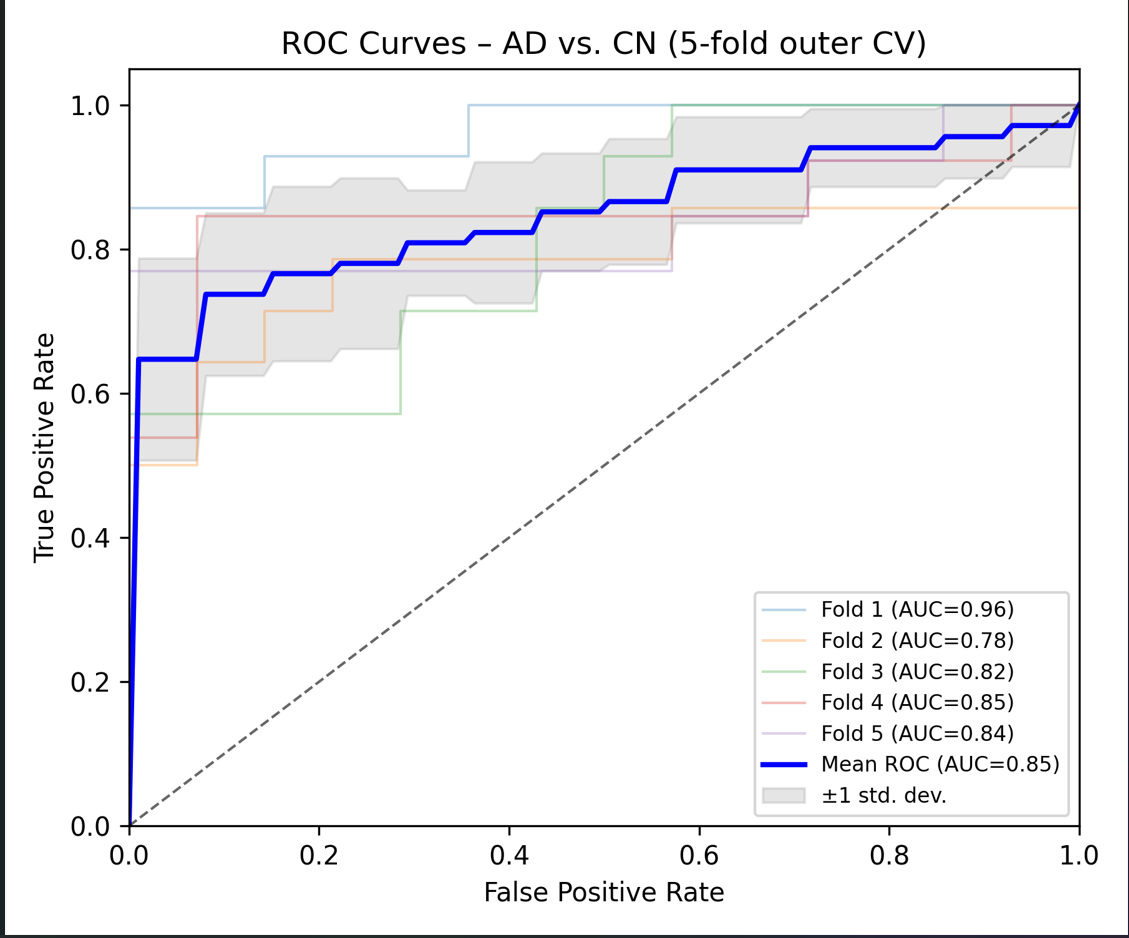

## Confusion Matrix

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with np.load(r"H:\Master's Thesis\pipeline\results\nested_cv_results.npz") as data:
    cms = data["confusion_matrices"]  # list of 2x2 arrays

# Aggregate (sum) all fold matrices
total_cm = np.sum(cms, axis=0).astype(int)

plt.figure(figsize=(5, 4))
sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN (pred)', 'AD (pred)'],
            yticklabels=['CN (true)', 'AD (true)'])
plt.title('Aggregated Confusion Matrix (5 outer folds)')
plt.tight_layout()
plt.savefig(r"H:\Master's Thesis\pipeline\results\confusion_matrix.tif", dpi=300, format='tiff')
plt.close()
print("Confusion matrix figure saved.")

Confusion matrix figure saved.


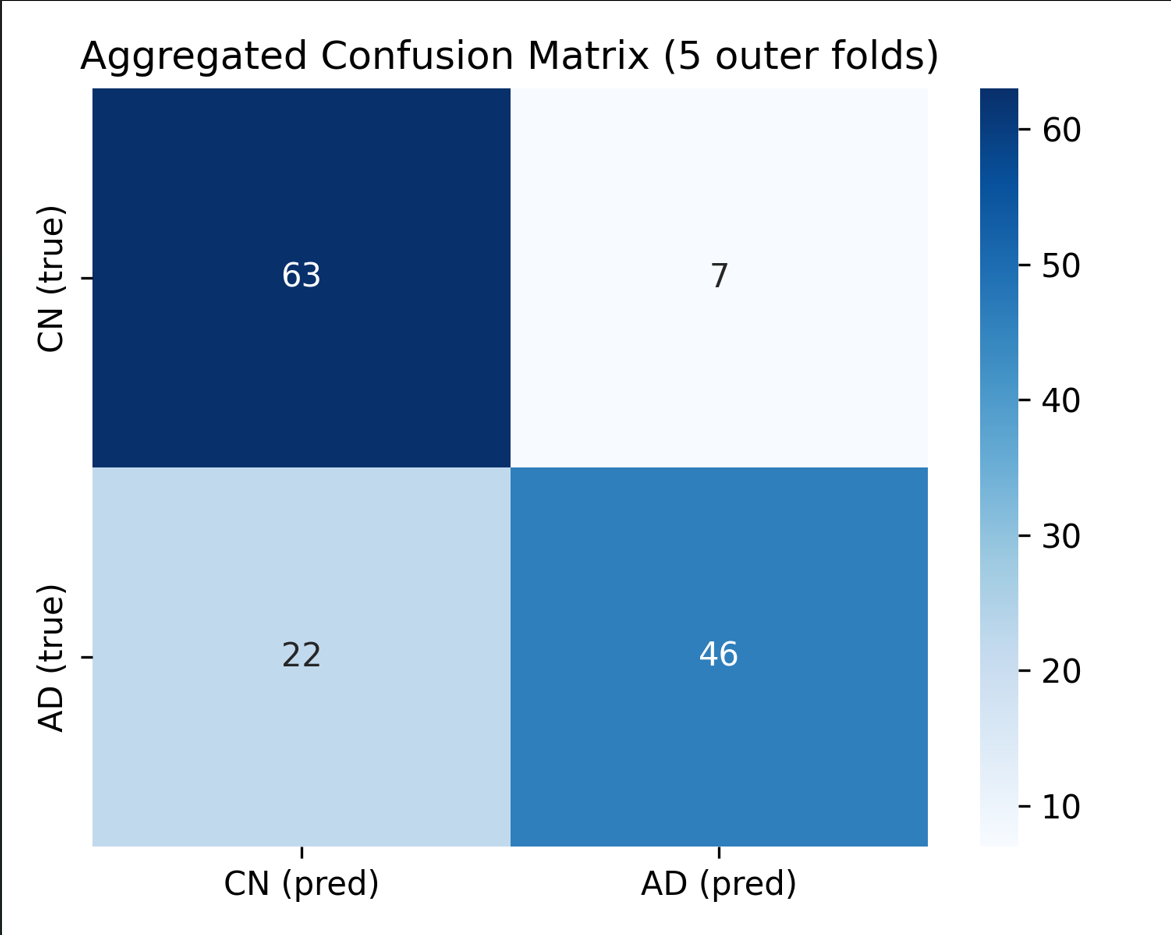